Simple Matplotlib Plotter (No PyROOT)
Loading data files...
  EGamma_F.root: 502.0 events
  EGamma_E.root: 151.0 events
  EGamma_G.root: 72.0 events
Total data events: 725.0

Loading MC samples...
  TTG_PTG10to100: 5.0 events
  TTTT: 0.2 events
  DYGTo2LG_MLL50_PTG200toInf: 32.4 events
  DYGTo2LG_MLL50_PTG100to200: 36.1 events
  TTZ_NoFullyHad: 24.5 events
  QCD_Pt-170to300_MuEnriched: 1.9 events
  WW_pythia: 9.4 events
  WJets: 8.8 events
  TTLL_powheg: 514.0 events
  WWZ: 6.2 events
  DYJets: 14448.8 events
  TTHToNonbb: 1.3 events
  WZTo3LNu_powheg: 53.3 events
  ST_tW_antitop_Semilep: 1.2 events
  QCD_Pt-1000toInf_MuEnriched: 0.0 events
  ST_tW_top_Semilep: 0.9 events
  ST_tch_antitop: 0.5 events
  QCD_Pt-300to470_MuEnriched: 0.2 events
  MuonEG_E: 395.0 events
  TTLJ_powheg: 33.7 events
  QCD_Pt-600to800_MuEnriched: 0.1 events
  ZZTo4L_powheg: 5.1 events
  MuonEG_G: 169.0 events
  QCD_Pt-470to600_MuEnriched: 0.1 events
  ST_sch_antitop_Lep: 0.1 events
  ST_tW_top_Lep: 21.5 events


AttributeError: This method only works with the ScalarFormatter

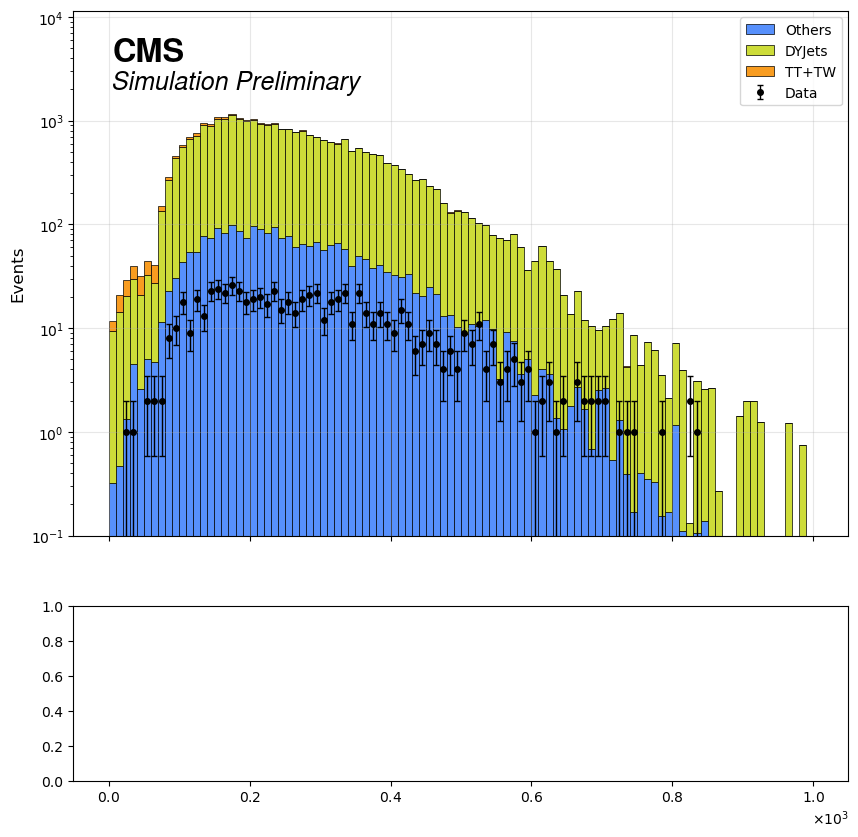

In [4]:
#!/usr/bin/env python3

import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from tqdm import tqdm

import cmsstyle as CMS
import mplhep as hep

# 데이터 디렉토리
data_dir = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002/2022EE/"

# ===============================================
# 1. 히스토그램 로드 함수
# ===============================================
def load_hist(file_path, hist_name, systematic="Central"):
    """ROOT 파일에서 히스토그램 데이터 추출"""
    try:
        file = uproot.open(file_path)
        
        # systematic 디렉토리 접근
        if systematic in file:
            directory = file[systematic]
            if hist_name in directory:
                hist = directory[hist_name]
                
                # 히스토그램 데이터 추출
                values = hist.values()  # 빈 contents
                edges = hist.axis().edges()  # 빈 edges
                errors = hist.errors()  # 빈 errors (있으면)
                
                return values, edges, errors
        
        print(f"Warning: {hist_name} not found in {file_path}")
        return None, None, None
        
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None, None

# ===============================================
# 2. 데이터 합치기
# ===============================================
def load_data(data_dir, hist_name):
    """EGamma 데이터 합치기"""
    print("Loading data files...")
    
    data_files = glob.glob(os.path.join(data_dir, "*.root"))
    
    combined_values = None
    combined_errors_sq = None
    edges = None
    total_events = 0
    
    for file_path in data_files:
        filename = os.path.basename(file_path)
        
        # 데이터 파일만 선택
        if filename.startswith("EGamma"):
            values, bin_edges, errors = load_hist(file_path, hist_name)
            
            if values is not None:
                events = np.sum(values)
                print(f"  {filename}: {events:.1f} events")
                
                if combined_values is None:
                    combined_values = values.copy()
                    combined_errors_sq = errors**2 if errors is not None else values.copy()
                    edges = bin_edges
                else:
                    combined_values += values
                    if errors is not None:
                        combined_errors_sq += errors**2
                    else:
                        combined_errors_sq += values
                
                total_events += events
    
    combined_errors = np.sqrt(combined_errors_sq) if combined_errors_sq is not None else None
    
    print(f"Total data events: {total_events:.1f}\n")
    return combined_values, edges, combined_errors

# ===============================================
# 3. MC 샘플 로드
# ===============================================
def load_mc_samples(data_dir, hist_name):
    """모든 MC 샘플 로드"""
    print("Loading MC samples...")
    
    mc_samples = {}
    mc_files = glob.glob(os.path.join(data_dir, "*.root"))
    
    for file_path in mc_files:
        filename = os.path.basename(file_path)
        sample_name = filename.replace(".root", "")
        
        # 데이터 파일 제외
        if (filename.startswith("Muon_") or 
            filename.startswith("EGamma_") or
            filename.startswith("SingleMuon")):
            continue
        
        values, edges, errors = load_hist(file_path, hist_name)
        
        if values is not None:
            events = np.sum(values)
            mc_samples[sample_name] = {
                'values': values,
                'edges': edges,
                'errors': errors
            }
            print(f"  {sample_name}: {events:.1f} events")
    
    print(f"Total MC samples: {len(mc_samples)}\n")
    return mc_samples

# ===============================================
# 4. MC 그룹으로 합치기
# ===============================================
def group_mc_samples(mc_samples):
    """MC 샘플을 카테고리별로 그룹화"""
    groups = {
        "TT+TW": [],
        "DYJets": [],
        "Others": []
    }
    
    # 샘플을 그룹으로 분류
    for name, data in mc_samples.items():
        if name.startswith("TTLJ") or name.startswith("TTLL") or name.startswith("ST"):
            groups["TT+TW"].append(data)
        elif name.startswith("DYJets"):
            groups["DYJets"].append(data)
        else:
            groups["Others"].append(data)
    
    # 각 그룹을 하나로 합치기
    grouped_samples = {}
    edges = None
    
    for group_name, sample_list in groups.items():
        if not sample_list:
            continue
        
        combined_values = sample_list[0]['values'].copy()
        combined_errors_sq = sample_list[0]['errors']**2 if sample_list[0]['errors'] is not None else sample_list[0]['values'].copy()
        edges = sample_list[0]['edges']
        
        for sample in sample_list[1:]:
            combined_values += sample['values']
            if sample['errors'] is not None:
                combined_errors_sq += sample['errors']**2
            else:
                combined_errors_sq += sample['values']
        
        combined_errors = np.sqrt(combined_errors_sq)
        
        grouped_samples[group_name] = {
            'values': combined_values,
            'edges': edges,
            'errors': combined_errors
        }
        
        print(f"{group_name}: {np.sum(combined_values):.1f} events")
    
    return grouped_samples, edges

# ===============================================
# 5. 플롯 그리기 (matplotlib)
# ===============================================
def plot_comparison(data_values, data_edges, data_errors, 
                   mc_grouped, output_name, logy=True):
    """Data vs MC 비교 플롯"""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), 
                                     gridspec_kw={'height_ratios': [3, 1]},
                                     sharex=True)
    
    # 빈 centers 계산
    bin_centers = (data_edges[:-1] + data_edges[1:]) / 2
    bin_widths = data_edges[1:] - data_edges[:-1]
    
    # ===== Upper panel: Data vs MC Stack =====
    
    # MC 스택 그리기
    colors = {
        "TT+TW": '#f89c20',  # Orange
        "DYJets": '#CDDC39',  # Lime
        "Others": '#5790fc'   # Blue
    }
    
    # 스택을 위한 bottom 계산
    bottom = np.zeros(len(bin_centers))
    total_mc = np.zeros(len(bin_centers))
    
    # 그룹 순서 (스택용)
    group_order = ["Others", "DYJets", "TT+TW"]
    
    for group_name in group_order:
        if group_name in mc_grouped:
            values = mc_grouped[group_name]['values']
            ax1.bar(bin_centers, values, width=bin_widths, 
                   bottom=bottom, label=group_name,
                   color=colors[group_name], edgecolor='black', linewidth=0.5)
            bottom += values
            total_mc += values
    
    # Data 그리기
    if data_values is not None:
        ax1.errorbar(bin_centers, data_values, yerr=data_errors,
                    fmt='o', color='black', markersize=4,
                    label='Data', capsize=2, linewidth=1)
    
    # 설정
    ax1.set_ylabel('Events', fontsize=12)
    if logy:
        ax1.set_yscale('log')
        ax1.set_ylim(0.1, max(np.max(data_values) if data_values is not None else 0, 
                              np.max(total_mc)) * 10)
    else:
        ax1.set_ylim(0, max(np.max(data_values) if data_values is not None else 0, 
                           np.max(total_mc)) * 1.3)
    
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # CMS label
    hep.cms.text("Simulation Preliminary", loc=2, ax=ax1, fontsize=18)
    #ax1.text(0.05, 0.85, r"$Z'(500GeV) \to \tau \tau$, PU=200",
    #transform=ax1.transAxes, fontsize=15, va='top', ha='left',
    #bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax1.ticklabel_format(style="sci", scilimits=(-3, 3), useMathText=True)
    ax1.get_yaxis().get_offset_text().set_position((-0.085, 1.05))
    
    # ===== Lower panel: Ratio =====
    
    if data_values is not None and np.sum(total_mc) > 0:
        # Ratio 계산
        ratio = np.where(total_mc > 0, data_values / total_mc, 0)
        ratio_error = np.where(total_mc > 0, data_errors / total_mc, 0)
        
        # MC uncertainty band
        mc_rel_error = np.where(total_mc > 0, 
                               np.sqrt(total_mc) / total_mc, 0)
        ax2.fill_between(bin_centers, 1 - mc_rel_error, 1 + mc_rel_error,
                        alpha=0.3, color='gray', label='MC stat. unc.')
        
        # Data ratio
        ax2.errorbar(bin_centers, ratio, yerr=ratio_error,
                    fmt='o', color='black', markersize=4,
                    capsize=2, linewidth=1)
        
        # Horizontal line at 1
        ax2.axhline(y=1, color='red', linestyle='--', linewidth=1)
    
    ax2.set_xlabel('Top jet number', fontsize=12)
    ax2.set_ylabel('Data / MC', fontsize=11)
    ax2.set_ylim(0.5, 1.5)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"{output_name}.png", dpi=150, bbox_inches='tight')
    plt.savefig(f"{output_name}.pdf", bbox_inches='tight')
    print(f"Saved: {output_name}.png, {output_name}.pdf")
    plt.close()

# ===============================================
# 6. 메인 실행
# ===============================================
def main():
    """메인 함수"""
    
    hist_name = "DYCR_Resolved_MM_pt"
    output_name = "test_plot_matplotlib"
    
    print("="*50)
    print("Simple Matplotlib Plotter (No PyROOT)")
    print("="*50)
    
    # 1. 데이터 로드
    data_values, data_edges, data_errors = load_data(data_dir, hist_name)
    
    # 2. MC 로드
    mc_samples = load_mc_samples(data_dir, hist_name)
    
    # 3. MC 그룹화
    mc_grouped, mc_edges = group_mc_samples(mc_samples)
    
    # 4. 플롯 그리기
    plot_comparison(data_values, data_edges, data_errors, 
                   mc_grouped, output_name, logy=True)
    
    print("\nDone!")

if __name__ == "__main__":
    main()